# Bank Marketing Dataset Machine Learning Project

Dataset address: [Bank Marketing Dataset](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project#bank-marketing-dataset-machine-learning-project)


The "Bank Marketing Data Set" from the UCI Machine Learning Repository is related with direct marketing campaigns (phone calls) of a Portuguese banking institution.

The classification goal is to predict if the client will subscribe a term deposit (variable y). You can find a description of the attributes at the original UCI URL, https://archive.ics.uci.edu/ml/datasets/Bank+Marketing. In this project we build two classifiers for this data set: a decision tree, and a random forest. We use ROC AUC score as an evaluation metric to compare the performance of the two classifiers.

## Approach

- We devise two feature engineering appraoches: First, Label encoding of Education and One-hot encoding of categorical fields and second, ordinal encoding of Education and One-hot encoding of categorical fields

- Create pipeline of Feaure Engineering and the ML model i.e. Decision Tree or Random Forest.

In [1]:
# package

# basic packages
import os

# analysis packages
import numpy as np
import pandas as pd

# statistical package
import scipy.stats as stats

# plot packages
import matplotlib.pylab as plt
import seaborn as sns

# Time package
import datetime

### 1. Import dataset by pandas

In [2]:
PATH = os.getcwd()
NAME_DATASET = "bank-additional-full.csv"
PATH_DATASET = os.path.join(PATH, NAME_DATASET)
main_data = pd.read_csv(PATH_DATASET, sep=';') # sep on ;

In [3]:
main_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [4]:
main_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 1. Customer Demographics
* **age**: Customer's age.
* **job**: Type of job (admin, blue-collar, technician, etc.).
* **marital**: Marital status.
* **education**: Education level.

### 2. Credit/Financial Status
* **default**: Does the customer have credit in default? (yes/no)
* **housing**: Does the customer have a housing loan? (yes/no)
* **loan**: Does the customer have a personal loan? (yes/no)

### 3. Last Contact Info
* **contact**: Contact communication type (cellular, telephone).
* **month**: Last contact month.
* **day_of_week**: Last contact day of the week.
* **duration**: Last contact duration (in seconds). **Important Note:** This column strongly causes *Data Leakage*. A high duration often means the customer has already said "yes" by the end of the call. In realistic modeling, this column is usually removed.

### 4. Marketing Campaign Info
* **campaign**: Number of contacts performed during this campaign for this client.
* **pdays**: Number of days that passed by after the client was last contacted from a previous campaign (999 means client was not previously contacted).
* **previous**: Number of contacts performed before this campaign and for this client.
* **poutcome**: Outcome of the previous marketing campaign (success, failure, nonexistent).

### 5. Economic Context
* **emp.var.rate**: Employment variation rate.
* **cons.price.idx**: Consumer price index.
* **cons.conf.idx**: Consumer confidence index.
* **euribor3m**: Euribor 3 month rate.
* **nr.employed**: Number of employees.

### 6. Target
* **y**: Target variable. Has the client subscribed a term deposit? (yes/no).

### 2. Describe data


#### 2.1. Information

Using the `info` method, we learn about the nature of each column and their data types.


In [5]:
main_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

#### 2.2. describe method

Using the `describe` method, we analyze the data columns in terms of maximum, minimum, standard deviation, and count.


In [6]:
main_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


#### 2.3. Null

Examine the number of null values. Do not have any null values.

In [7]:
main_data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### 3. Data Analysis

In [8]:
an_data = main_data.copy()

#### 3.1. How many customers are there for each age?


In [45]:
age_count = pd.DataFrame(an_data.groupby("age")["age"].agg(sum).rename("age_sum")).reset_index()
age_count

,age,age_sum
0,17,85
1,18,504
2,19,798
3,20,1300
4,21,2142
...,...,...
73,91,182
74,92,368
75,94,94
76,95,95


In [47]:
age_count.head(2)

,age,age_sum
0,17,85
1,18,504


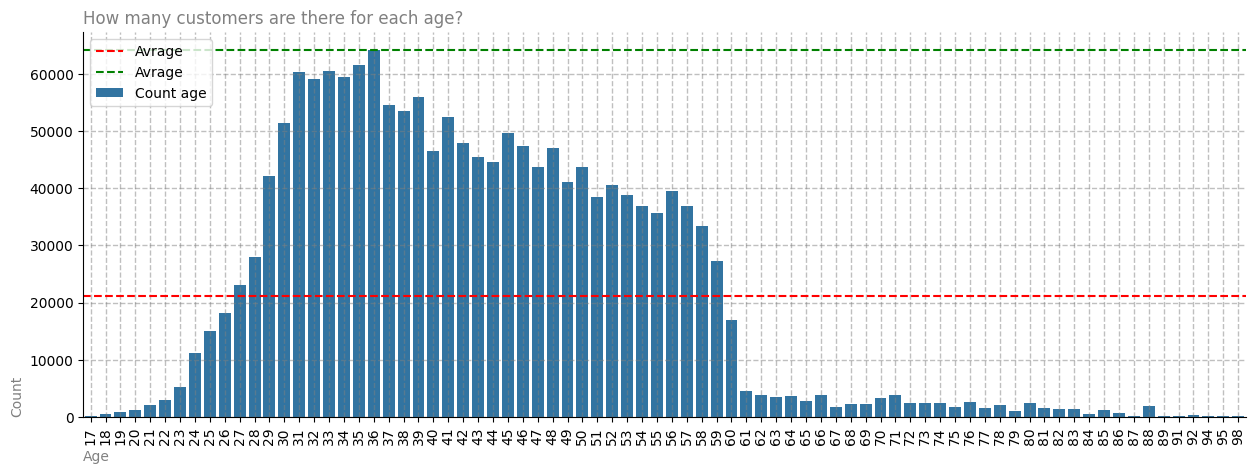

In [90]:
age_count = pd.DataFrame(an_data.groupby("age")["age"]
                         .agg(sum)
                         .rename("age_sum")).reset_index()

fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(data=age_count, x="age", y="age_sum", label="Count age")

ax.axhline(y = age_count["age_sum"].mean(),
           color="red",
           linestyle="--",
           label="Avrage")

ax.axhline(y = age_count["age_sum"].max(),
           color="green",
           linestyle="--",
           label="Avrage")

plt.xticks(rotation=90)

ax.set_xlabel("Age",
              color="gray",
              loc="left")
ax.set_ylabel("Count",
              color="gray",
              loc="bottom")
ax.set_title("How many customers are there for each age?",
             color="gray",
             loc="left")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linewidth=1, linestyle="--", alpha=0.5, color="gray")

ax.legend(loc="upper left")
plt.show()